# Detección de Objetos


In [1]:
import importlib
from ultralytics import YOLO
import supervision as sv
import cv2
import sys
sys.path.append("..")

from media_tools import video_tools as vt
from media_tools import image_tools as it
importlib.reload(vt)
importlib.reload(it)


<module 'media_tools.image_tools' from '/home/adrian/IA-Futbol/object_detection/../media_tools/image_tools.py'>

In [ ]:
#Entrenamiento del modelo 

DATA_PATH = "../Dataset/ObjectDetection/data.yaml" #Ruta al dataset
OUTPUT_PATH = "ObjectDetection/models" #Ruta donde se almacena el modelo entrenado

model = YOLO('yolov8m.yaml')  #Modelo sin pesos
model.train(
    data=DATA_PATH,      
    epochs=20,
    imgsz=(640, 1152),
    batch=4,
    device=0             
)

In [16]:
model = YOLO('models/train3/weights/best.pt')
video_path = 'video_prueba.mp4'

vt.write_video(video_path,output_path="video_prueba_BB.mp4",object_model=model,stylized_ob_detection=False)
vt.display_video("video_prueba_BB.mp4")

Processing: 100%|██████████| 1349/1349 [01:23<00:00, 16.12it/s]


In [21]:
vt.write_video(video_path,output_path="video_prueba_BB3.mp4",object_model=model,stylized_ob_detection=True,text_label=True)
vt.display_video("video_prueba_BB3.mp4")

Processing: 100%|██████████| 1349/1349 [01:22<00:00, 16.27it/s]


# Distinción de equipos

Se hará una distinción de los jugadores según al equipo al que pertenecen.




### Método 1

Recortar las imagenes de los jugadores a lo largo del partido y usar técnicas de clustering para agruparlos en 2 grupos


In [6]:
model = YOLO('models/train3/weights/best.pt')
video_path = 'video_prueba.mp4'

crops = vt.extract_crops(video_path,model,ids=[2],crop_number=50)

100%|██████████| 50/50 [00:03<00:00, 15.53it/s]


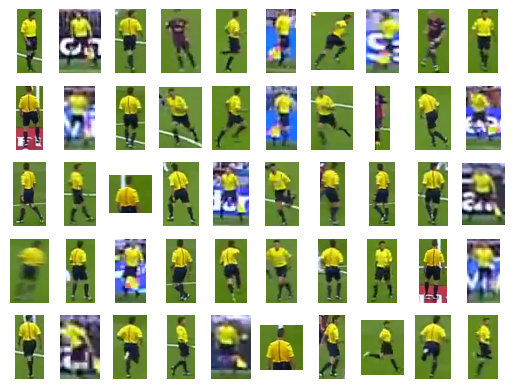

In [7]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(5, 10)
number_crop = 0

for i in range(0,5):
    for j in range(0,10):

        axs[i,j].imshow(cv2.cvtColor(crops[number_crop], cv2.COLOR_BGR2RGB))
        axs[i,j].axis('off')
        number_crop +=1

        
plt.show()

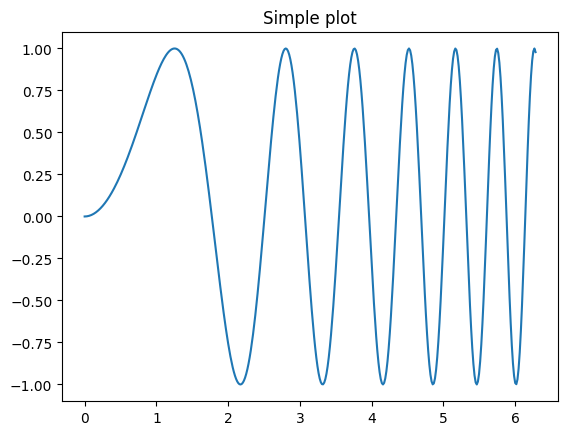

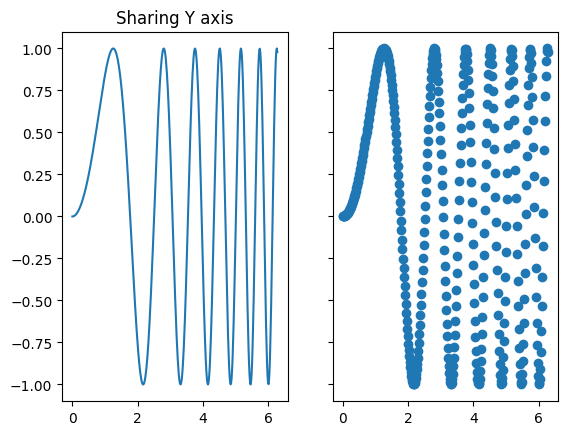

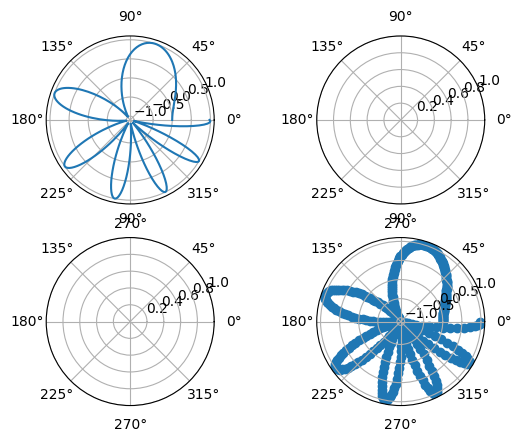

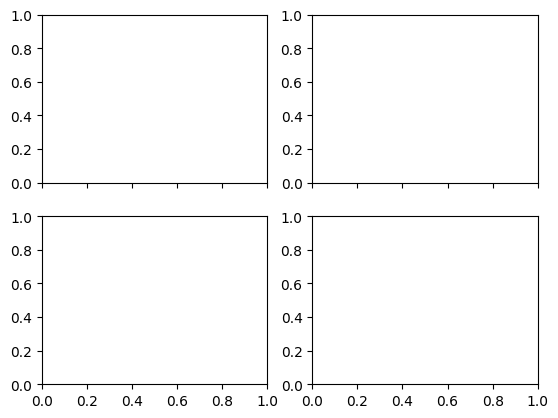

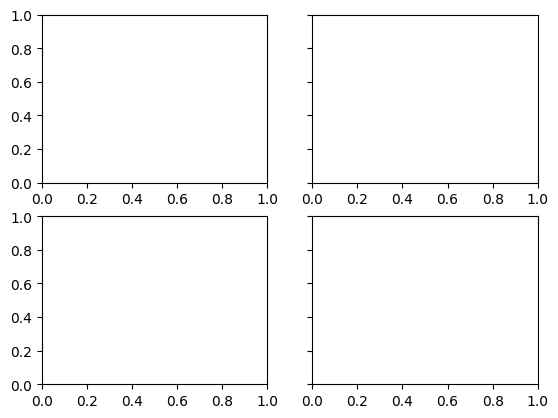

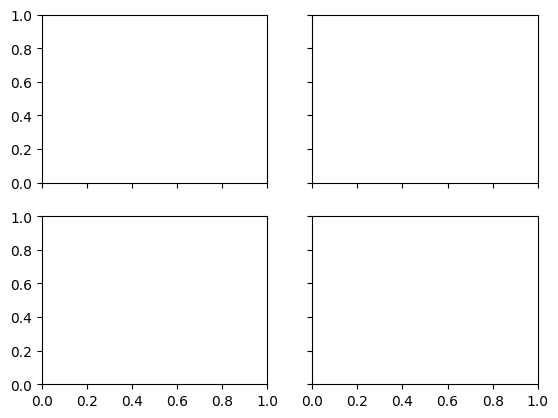

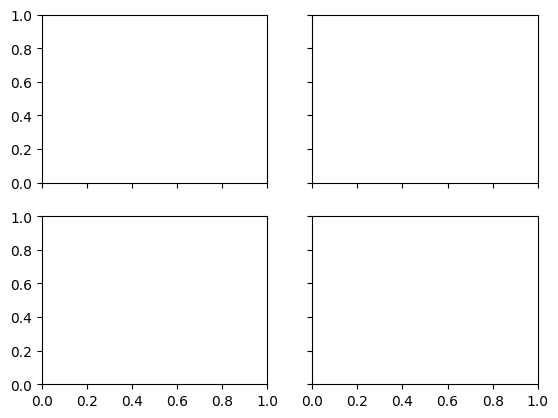

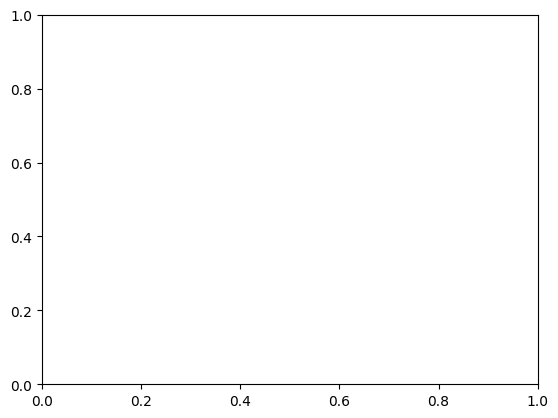

In [16]:

import numpy as np# First create some toy data:
x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x**2)

# Create just a figure and only one subplot
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_title('Simple plot')

# Create two subplots and unpack the output array immediately
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
ax1.plot(x, y)
ax1.set_title('Sharing Y axis')
ax2.scatter(x, y)

# Create four polar Axes and access them through the returned array
fig, axs = plt.subplots(2, 2, subplot_kw=dict(projection="polar"))
axs[0, 0].plot(x, y)
axs[1, 1].scatter(x, y)

# Share a X axis with each column of subplots
plt.subplots(2, 2, sharex='col')

# Share a Y axis with each row of subplots
plt.subplots(2, 2, sharey='row')

# Share both X and Y axes with all subplots
plt.subplots(2, 2, sharex='all', sharey='all')

# Note that this is the same as
plt.subplots(2, 2, sharex=True, sharey=True)

# Create figure number 10 with a single subplot
# and clears it if it already exists.
fig, ax = plt.subplots(num=10, clear=True)